# Regression Model For Respiratory Disease Deaths

In [800]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import numpy as np

# Load the cleaned dataset
df = pd.read_csv("./datasets/processed_dataset.csv")
df["State"] = df["State"].astype('category')
df["County"] = df["County"].astype('category')

# Preview the data
df.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,...,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,Deaths,Population,Crude Rate,Cause
0,Alabama,Baldwin,2018,270,232,38,0,0,0,0,...,37,0,0,194,76,0,225.0,218022.0,103.2,respiratory_diseases
1,Alabama,Clay,2018,110,86,24,0,0,0,0,...,36,0,0,0,110,0,24.0,13275.0,180.8,respiratory_diseases
2,Alabama,Colbert,2018,277,235,42,0,0,0,0,...,37,0,0,184,93,0,97.0,54762.0,177.1,respiratory_diseases
3,Alabama,DeKalb,2018,350,302,48,0,0,0,0,...,36,0,0,286,64,0,111.0,71385.0,155.5,respiratory_diseases
4,Alabama,Elmore,2018,222,203,19,0,0,0,0,...,33,0,0,222,0,0,93.0,81887.0,113.6,respiratory_diseases


In [801]:
# Check the variables
df.dtypes

State                                  category
County                                 category
Year                                      int64
Days with AQI                             int64
Good Days                                 int64
Moderate Days                             int64
Unhealthy for Sensitive Groups Days       int64
Unhealthy Days                            int64
Very Unhealthy Days                       int64
Hazardous Days                            int64
Max AQI                                   int64
90th Percentile AQI                       int64
Median AQI                                int64
Days CO                                   int64
Days NO2                                  int64
Days Ozone                                int64
Days PM2.5                                int64
Days PM10                                 int64
Deaths                                  float64
Population                              float64
Crude Rate                              

## Dataset Analysis

In [802]:
df.describe()

,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,Deaths,Population,Crude Rate
count,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6.174000e+03,6174.000000
mean,2020.977412,329.594385,237.126008,87.907067,3.461439,0.845434,0.182156,0.072281,129.635528,60.445466,40.344789,0.178767,3.088416,161.974992,154.766538,9.585673,211.740239,2.909888e+05,100.254049
std,2.003581,67.710547,70.661562,63.380046,8.670397,3.618349,1.601665,0.706093,143.063217,15.279564,9.668227,5.172511,20.844846,114.364321,123.466126,43.834727,338.232477,5.832741e+05,40.316302
min,2018.000000,7.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,4.074000e+03,20.500000
25%,2019.000000,342.000000,199.000000,32.000000,0.000000,0.000000,0.000000,0.000000,87.000000,52.000000,36.000000,0.000000,0.000000,75.000000,5.000000,0.000000,48.000000,4.338825e+04,69.900000
50%,2021.000000,363.000000,239.000000,79.000000,1.000000,0.000000,0.000000,0.000000,106.000000,59.000000,41.000000,0.000000,0.000000,161.000000,162.000000,0.000000,109.000000,1.142910e+05,94.600000
75%,2023.000000,365.000000,290.000000,132.000000,3.000000,0.000000,0.000000,0.000000,142.000000,66.000000,45.000000,0.000000,0.000000,243.000000,251.000000,0.000000,238.000000,2.979085e+05,124.300000
max,2024.000000,366.000000,365.000000,302.000000,109.000000,69.000000,75.000000,31.000000,8368.000000,216.000000,122.000000,259.000000,365.000000,366.000000,366.000000,366.000000,5887.000000,1.010552e+07,305.400000


### Remove Columns
We can remove the `Cause` columns since all rows contain death info related to respiratory diseases as that is the focus of our project. We can also remove `Days with AQI` since the column is the sum of the different day counts meaning we have perfect multicollinearity.

In [803]:
df = df.drop(columns=["Cause", "Days with AQI"])

### Transform Targets
Based on the column statistics above, we can see significant right skew for `Deaths` based on difference bwteen mean and median. `Crude Rate` also shows some skew but it is less severe. We can log transform both target variables to help address the skew since having skew in our targets can skew the residuals violating the assumptions of the linear regression model.

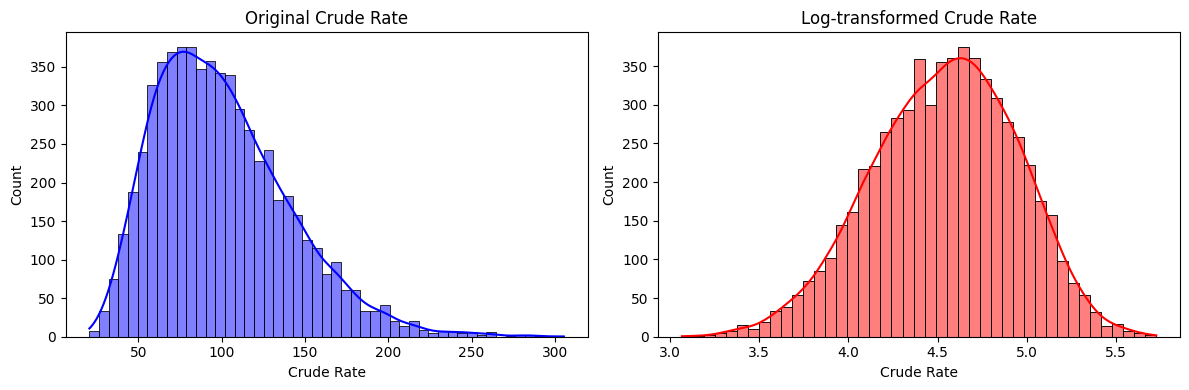

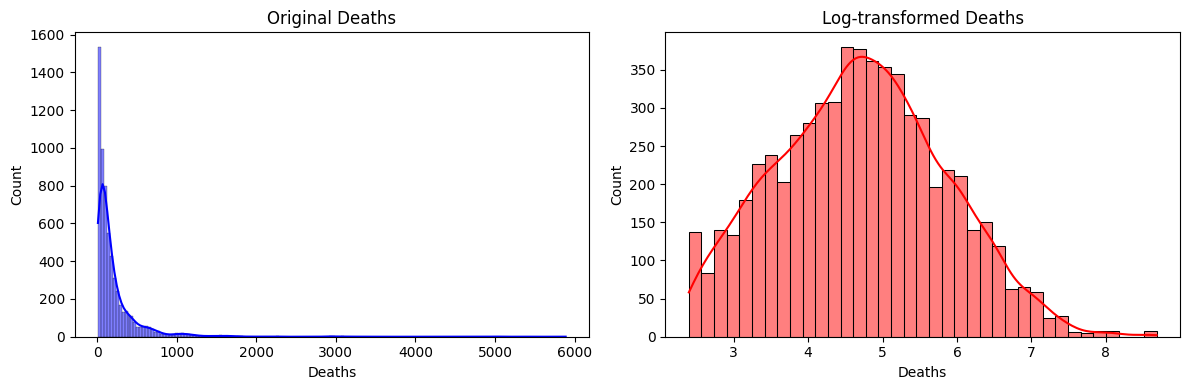

In [804]:
targets = ["Crude Rate", "Deaths"]

for col in targets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

### Transform Features
Based on the column stats we can see that `Max AQI` and `Population` demonstrate significant right skew so we can also apply a log transformation to limit the effect of extreme values.

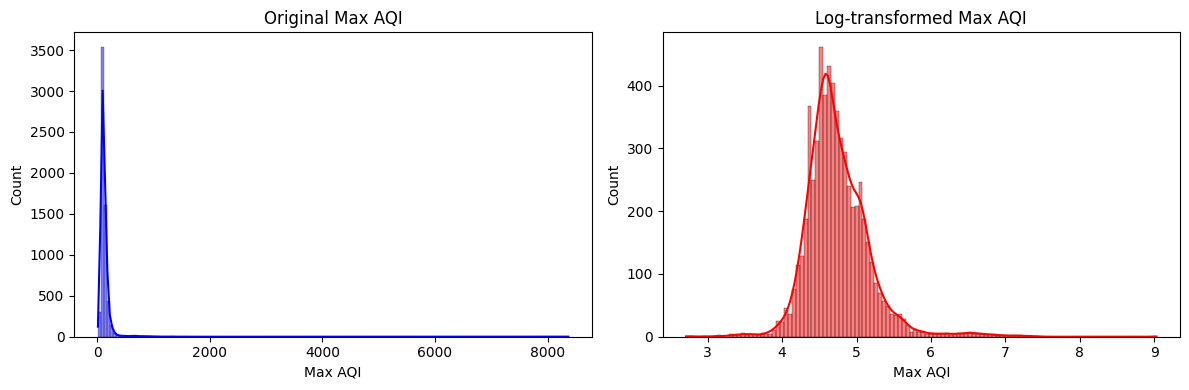

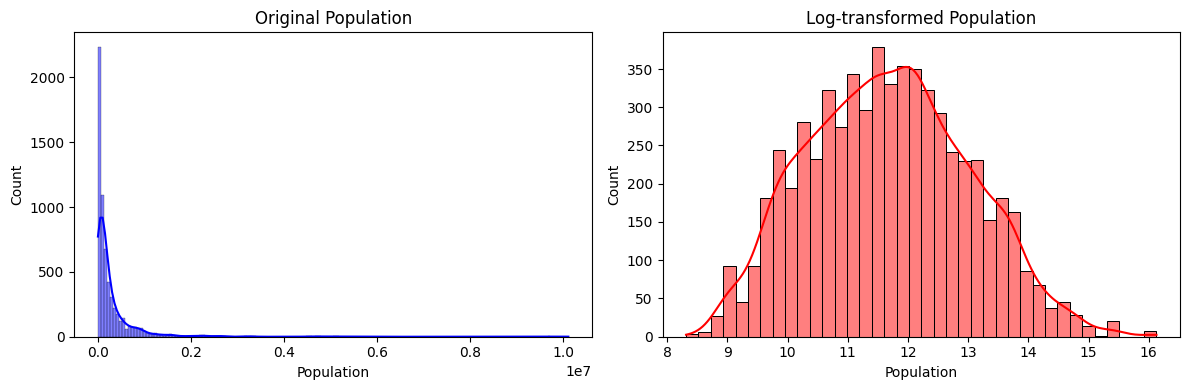

In [805]:
covariates = ["Max AQI", "Population"]

for col in covariates:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

Based on the column stats, there appears to be significant zero inflation meaning that many of the values are 0. If we look at `Unhealthy Days`, `Very Unhealthy Days`, `Hazardous Days`, `Days CO`, `Days NO2`, and `Days PM10` they have a 75% value of 0 indicating significant zero inflation. This indicates that the events these covariates are counting are relatively rare in many places, so it would be good to add a binary value for each covariate to allow the model to have intercept shift for places that don't experience these rare events. The model can more easily handle the difference between these events never occuring or rarely occurring.

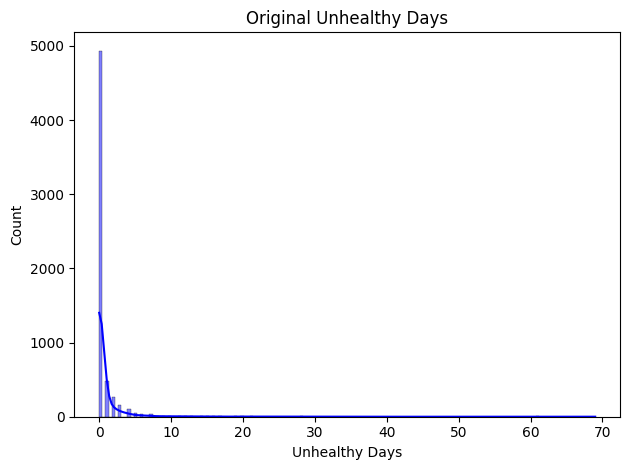

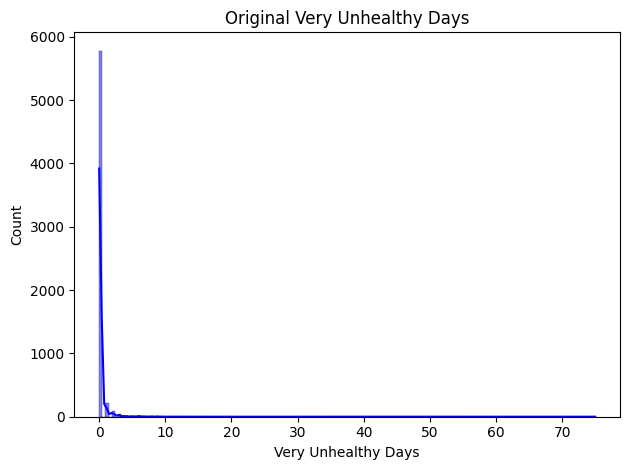

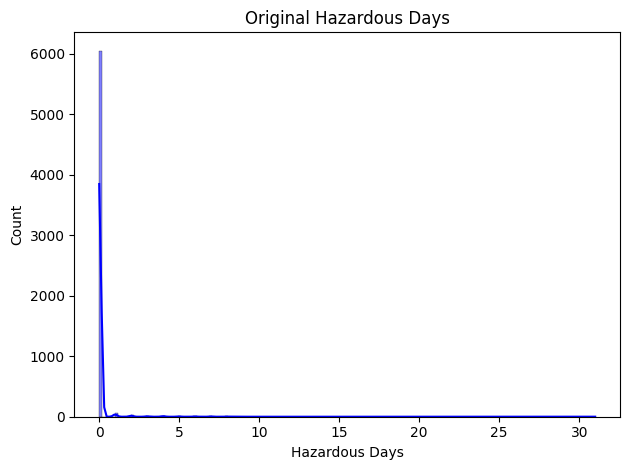

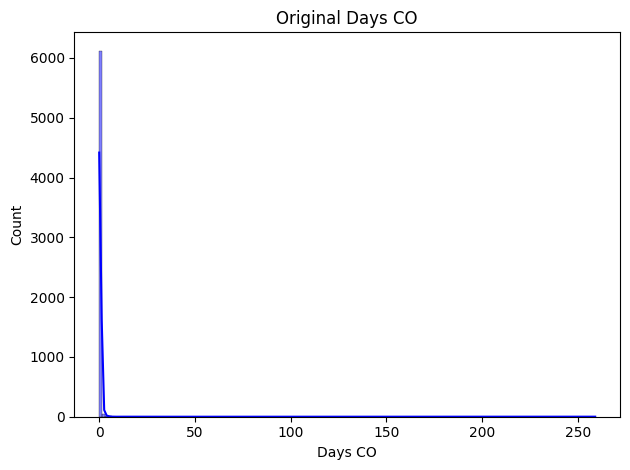

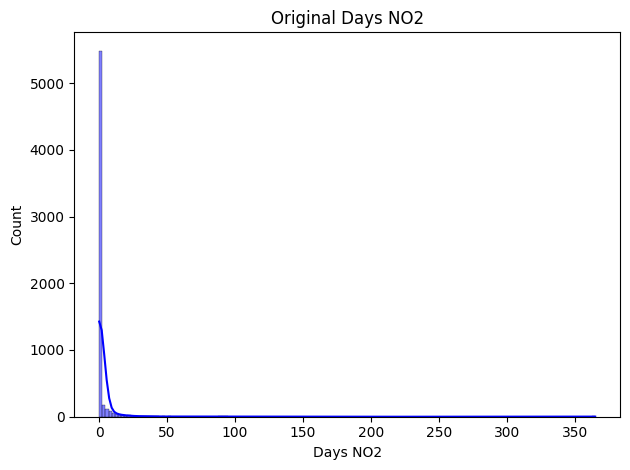

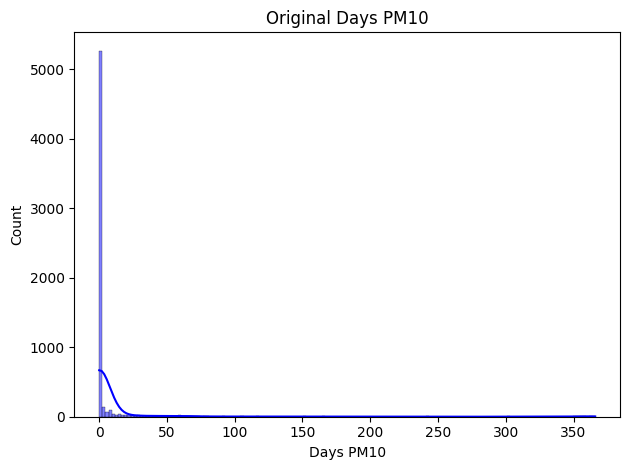

In [806]:
zero_inflated_covariates = ['Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days', 'Days CO', 'Days NO2', 'Days PM10']

for col in zero_inflated_covariates:    
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f"Original {col}")
    
    plt.tight_layout()
    plt.show()

In [807]:
# Add binary terms
for col in zero_inflated_covariates:
    df[f'{col}_binary'] = (df[col] > 0).astype(int)
df.head()

,State,County,Year,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,...,Days PM10,Deaths,Population,Crude Rate,Unhealthy Days_binary,Very Unhealthy Days_binary,Hazardous Days_binary,Days CO_binary,Days NO2_binary,Days PM10_binary
0,Alabama,Baldwin,2018,232,38,0,0,0,0,4.584967,...,0,5.420535,12.292356,4.646312,0,0,0,0,0,0
1,Alabama,Clay,2018,86,24,0,0,0,0,4.234107,...,0,3.218876,9.493713,5.202907,0,0,0,0,0,0
2,Alabama,Colbert,2018,235,42,0,0,0,0,4.543295,...,0,4.584967,10.910770,5.182345,0,0,0,0,0,0
3,Alabama,DeKalb,2018,302,48,0,0,0,0,4.442651,...,0,4.718499,11.175857,5.053056,0,0,0,0,0,0
4,Alabama,Elmore,2018,203,19,0,0,0,0,4.276666,...,0,4.543295,11.313108,4.741448,0,0,0,0,0,0


### Correlation analysis

In this part we performed correlation analysis on the numeric predictors. Categorical vairables such as `County` and `State` will be excluded.

In [808]:
corr_df = df.drop(columns=["County", "State", "Deaths", "Crude Rate"]).dropna(subset=["Population"])
corr_matrix = corr_df.corr(numeric_only=True)

#### Correlation Matrix

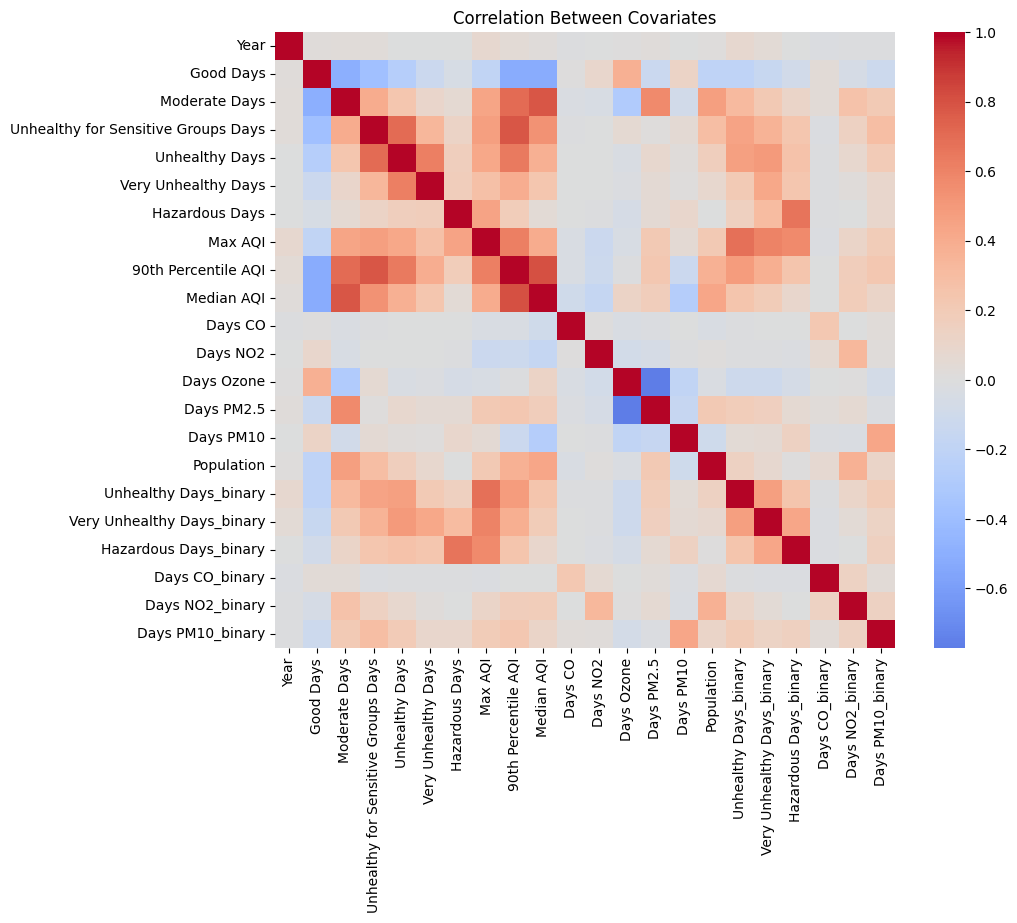

In [809]:
# Heatmap Visualization
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Covariates")
plt.show()    

The heatmap visualizes the strength and direction of correlations among the numeric variables. Warmer colors(red) suggests positive correlation, while cooler colors(blue) represent negative correlations. 

From this heatmap, we observe several strong positive correlations between the AQI-related variables including Median AQI, 90th Percentile AQI, Max AQI, and the number of Moderate, Unhealthy, and Very Unhealthy Days. This is expected because they measure similar aspects of air pollution severity.  

At the same time, the variable Good Days appears to have negative correlations with many of the pollution indicators. This makes sense because counties that experience more days with good air quality generally have fewer days with higher pollution levels.

Based on this heatmap, we have evidence of multicollinearity and should drop columns with high correlation before fitting the regression model.

#### Variance Inflation Factor

In [810]:
def calc_vifs(df):
    df_const = add_constant(df)
    vif = pd.DataFrame()
    vif["variable"] = df_const.columns
    vif["VIF"] = [variance_inflation_factor(df_const.values, i) 
                  for i in range(df_const.shape[1])]
    return vif.set_index("variable").drop("const")

In [811]:
calc_vifs(corr_df)

/Users/kevinjacob/Library/Mobile Documents/com~apple~CloudDocs/UCSD/MATH 189/MATH189_env/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
variable,
Year,1.015784
Good Days,inf
Moderate Days,inf
Unhealthy for Sensitive Groups Days,inf
Unhealthy Days,inf
Very Unhealthy Days,inf
Hazardous Days,inf
Max AQI,4.539715
90th Percentile AQI,9.191586


If we look at the VIF values, most of them appear to be really high with inf values indicating severe multicollinarity as suggested by the covariance matrix. We can remove inf values one by one where we chose to remove the inf value with the lowest correlation to our target values.

In [812]:
remaining = corr_df.columns.tolist()
iteration = 1

while True:
    vif_df = calc_vifs(df[remaining].dropna()).sort_values("VIF", ascending=False)
    print(f"\nIteration {iteration}")
    print(vif_df.round(2).to_string())

    has_inf  = np.isinf(vif_df["VIF"]).any()
    max_vif  = vif_df["VIF"].replace(np.inf, np.nan).max()

    if not has_inf and max_vif < 5:
        print("\nDone.")
        break

    if has_inf:
        inf_vars = vif_df[np.isinf(vif_df["VIF"])].index.tolist()
        target_corrs = {v: abs(df[v].corr(df['Deaths'])) for v in inf_vars}
        worst = min(target_corrs, key=target_corrs.get)
    else:
        worst = vif_df["VIF"].idxmax()

    print(f"\nDropping: '{worst}'")
    remaining.remove(worst)
    iteration += 1

/Users/kevinjacob/Library/Mobile Documents/com~apple~CloudDocs/UCSD/MATH 189/MATH189_env/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Iteration 1
                                      VIF
variable                                 
Days NO2                              inf
Days Ozone                            inf
Moderate Days                         inf
Unhealthy for Sensitive Groups Days   inf
Unhealthy Days                        inf
Very Unhealthy Days                   inf
Hazardous Days                        inf
Days PM10                             inf
Days PM2.5                            inf
Days CO                               inf
Good Days                             inf
90th Percentile AQI                  9.19
Median AQI                           7.35
Max AQI                              4.54
Hazardous Days_binary                2.40
Unhealthy Days_binary                2.38
Very Unhealthy Days_binary           1.94
Population                           1.47
Days PM10_binary                     1.45
Days NO2_binary                      1.39
Days CO_binary                       1.08
Year                 

With the reduced set of covariates, we can see that we now have a set of covariates with a resonable VIF value.

In [813]:
calc_vifs(df[remaining].dropna())

,VIF
variable,
Year,1.014844
Good Days,1.750816
Moderate Days,2.238821
Unhealthy for Sensitive Groups Days,2.910105
Unhealthy Days,3.364452
Very Unhealthy Days,1.804632
Hazardous Days,1.854376
Max AQI,3.905834
Days CO,1.061236


## Fitting Regression Model

### Processed Dataset
Split the dataset into a train set and test set for evaluating the model later

In [814]:
in_features = remaining
df = df[in_features + ["Deaths","Crude Rate"]].dropna()
df.head()

,Year,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,Days CO,Days Ozone,Days PM10,Population,Unhealthy Days_binary,Very Unhealthy Days_binary,Hazardous Days_binary,Days CO_binary,Days NO2_binary,Days PM10_binary,Deaths,Crude Rate
0,2018,232,38,0,0,0,0,4.584967,0,194,0,12.292356,0,0,0,0,0,0,5.420535,4.646312
1,2018,86,24,0,0,0,0,4.234107,0,0,0,9.493713,0,0,0,0,0,0,3.218876,5.202907
2,2018,235,42,0,0,0,0,4.543295,0,184,0,10.910770,0,0,0,0,0,0,4.584967,5.182345
3,2018,302,48,0,0,0,0,4.442651,0,286,0,11.175857,0,0,0,0,0,0,4.718499,5.053056
4,2018,203,19,0,0,0,0,4.276666,0,222,0,11.313108,0,0,0,0,0,0,4.543295,4.741448


In [815]:
def split_data_by_year(group_df, train_frac=0.8, random_state=42):
    train_set = group_df.sample(frac=train_frac, random_state=random_state)
    test_set = group_df.drop(train_set.index)
    return train_set, test_set

train_list = []
test_list = []

for year, group_df in df.groupby('Year'):
    train_subset, test_subset = split_data_by_year(group_df, train_frac=0.8, random_state=42)
    train_list.append(train_subset)
    test_list.append(test_subset)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print(f"Train Set Size: {len(train_df)}")
print(f"Test Set Size: {len(test_df)}")

Train Set Size: 4939
Test Set Size: 1235


**Multiple Linear Regression Model**

To formally test the relationship between air pollution and respiratory-related deaths, a multiple linear regression model is created.

Respiratory deaths serve as the dependent variable, while pollution indicators such as Median AQI, PM2.5 days, and Ozone days serve as explanatory variables. 

In [816]:
X = train_df[in_features]
y = train_df["Deaths"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     3162.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:42:07   Log-Likelihood:                -1320.2
No. Observations:                4939   AIC:                             2678.
Df Residuals:                    4920   BIC:                             2802.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  20.9977      4.577      4.587      0.000      12.024      29.971
Year                                   -0.0125      0.002     -5.524      0.000      -0.017      -0.008
Good Days                              -0.0002   8.44e-05     -2.333      0.020      -0.000   -3.15e-05
Moderate Days                           0.0008      0.000      7.553      0.000       0.001       0.001
Unhealthy for Sensitive Groups Days    -0.0032      0.001     -3.324      0.001      -0.005      -0.001
Unhealthy Days                          0.0071      0.003      2.830      0.005       0.002       0.012
Very Unhealthy Days                    -0.0038      0.008     -0.450      0.653      -0.020       0.013
Hazardous Days                          0.0052      0.008      0.644      0.519      -0.011       0.021
Max AQI                                -0.1139      0.021     -5.520      0.000      -0.154      -0.073
Days CO                                 0.0019      0.001      1.485      0.138      -0.001       0.004
Days Ozone                              0.0002   4.91e-05      4.114      0.000       0.000       0.000
Days PM10                               0.0004      0.000      2.795      0.005       0.000       0.001
Population                              0.8161      0.004    200.849      0.000       0.808       0.824
Unhealthy Days_binary                  -0.0559      0.017     -3.276      0.001      -0.089      -0.022
Very Unhealthy Days_binary              0.0723      0.027      2.648      0.008       0.019       0.126
Hazardous Days_binary                   0.0465      0.046      1.018      0.309      -0.043       0.136
Days CO_binary                      -2.475e-05      0.032     -0.001      0.999      -0.063       0.063
Days NO2_binary                        -0.1209      0.013     -9.038      0.000      -0.147      -0.095
Days PM10_binary                       -0.0038      0.014     -0.276      0.783      -0.030       0.023
==============================================================================
Omnibus:                      245.490   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.964
Skew:                          -0.535   Prob(JB):                     3.99e-64
Kurtosis:                       3.524   Cond. No.                     2.08e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.08e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [817]:
exog = model.model.exog
names = model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: Year:  1.015
VIF: Good Days:  1.748
VIF: Moderate Days:  2.200
VIF: Unhealthy for Sensitive Groups Days:  3.007
VIF: Unhealthy Days:  3.804
VIF: Very Unhealthy Days:  3.051
VIF: Hazardous Days:  1.916
VIF: Max AQI:  3.958
VIF: Days CO:  1.057
VIF: Days Ozone:  1.552
VIF: Days PM10:  1.479
VIF: Population:  1.427
VIF: Unhealthy Days_binary:  2.299
VIF: Very Unhealthy Days_binary:  2.317
VIF: Hazardous Days_binary:  2.459
VIF: Days CO_binary:  1.081
VIF: Days NO2_binary:  1.201
VIF: Days PM10_binary:  1.443


Overall, the model explains about 19% of the variation in deaths (R-squared = 0.186), which is not surprising since mortality is influenced by dozens of factors beyond just air quality. One of the key findings is that Median AQI has a strong, significant relationshps with deaths. For every one unit increase in AQI, the model predicts roughly 15 additional deaths, and this held up with extremely high statistical confidence (p < 0.001). Days with Ozone also reached the same level of significance, showing a small negative coefficient, meaning more ozone days were weakly associated with fewer deaths. 

In [818]:
sns.regplot(data=df, x="Median AQI", y="Deaths")
plt.title("Relationship Between AQI and Respiratory Deaths")
plt.show()

KeyError: 'Median AQI'

The regression line shows an upward trend, suggesting a positive association between AQI levels and the numbers of deaths. This indicates that higher AQI levels tend to be linked with higher mortality counts. However, there appear to be some outliers, suggesting that factors beyond air quality may also influence mortality rates.

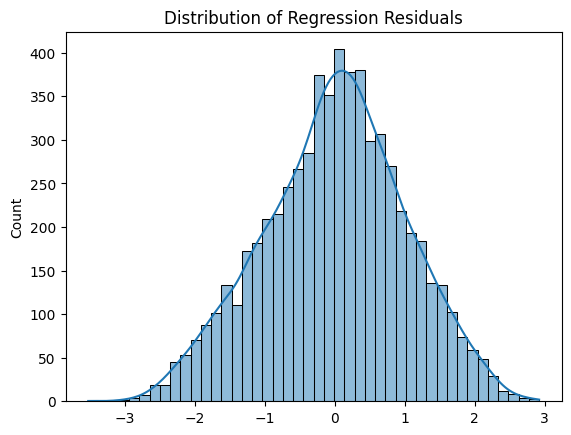

In [ ]:
residuals = model.resid

sns.histplot(residuals, kde=True)
plt.title("Distribution of Regression Residuals")
plt.show()

The residual distribution is examined to evaluate whether the regression model assumptions are satisfied. Ideally, the residuals should be approximately normally distributed around zero. In this case, the residual distribution appears to be right-skewed with a long tail, suggesting that the linear regression model may not fully capture the variation in the data, possibly due to outliers or other factors influencing mortality rates.

In [ ]:
# Convert needed columns to numeric
df["Crude Rate"] = pd.to_numeric(df["Crude Rate"], errors="coerce")
df["Median AQI"] = pd.to_numeric(df["Median AQI"], errors="coerce")
df["Days PM2.5"] = pd.to_numeric(df["Days PM2.5"], errors="coerce")
df["Days Ozone"] = pd.to_numeric(df["Days Ozone"], errors="coerce")

# Keep only complete rows for this model
rate_df = df.dropna(subset=["Crude Rate", "Median AQI", "Days PM2.5", "Days Ozone"]).copy()

print(rate_df[["Crude Rate", "Median AQI", "Days PM2.5", "Days Ozone"]].dtypes)
print(rate_df.shape)

Crude Rate    float64
Median AQI      int64
Days PM2.5      int64
Days Ozone      int64
dtype: object
(6174, 26)


In [ ]:
# Model 1: Regress raw respiratory death counts on air quality variables 
# to see how pollution measures relate to total deaths across county-year observations.
import statsmodels.formula.api as smf

model = smf.ols(
    formula='Deaths ~ Q("Median AQI") + Q("Days PM2.5") + Q("Days Ozone")',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Deaths   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     522.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          8.81e-303
Time:                        14:17:11   Log-Likelihood:                -8844.6
No. Observations:                6198   AIC:                         1.770e+04
Df Residuals:                    6194   BIC:                         1.772e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5021      0.063     

In [ ]:
# Model 2: Regress crude respiratory mortality rate on air quality variables so counties 
# are compared after adjusting for population size rather than raw death totals.
rate_model = smf.ols(
    formula='Q("Crude Rate") ~ Q("Median AQI") + Q("Days PM2.5") + Q("Days Ozone")',
    data=rate_df
).fit()

print(rate_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Q("Crude Rate")   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     118.9
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.50e-75
Time:                        14:17:11   Log-Likelihood:                -2986.9
No. Observations:                6174   AIC:                             5982.
Df Residuals:                    6170   BIC:                             6009.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.9683      0.025    2

In [ ]:
# Model 3: Regress crude respiratory mortality rate on air quality variables while also
#  controlling for year fixed effects to account for national time trends and year-specific shocks.
year_fe_model = smf.ols(
    formula='Q("Crude Rate") ~ Q("Median AQI") + Q("Days PM2.5") + Q("Days Ozone") + C(Year)',
    data=rate_df
).fit()

print(year_fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Q("Crude Rate")   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     46.98
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.49e-82
Time:                        14:17:11   Log-Likelihood:                -2955.6
No. Observations:                6174   AIC:                             5931.
Df Residuals:                    6164   BIC:                             5998.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           5.0422      0.027    1

In [ ]:
# Extract only the main pollution coefficients from the county and year 
# fixed effects model so the key results are easier to interpret.
county_year_fe_model.params[[
    'Q("Median AQI")',
    'Q("Days PM2.5")',
    'Q("Days Ozone")'
]]

NameError: name 'county_year_fe_model' is not defined

In [ ]:
# Extract the p-values for the main pollution coefficients from the county
#  and year fixed effects model to check which predictors remain statistically significant.
county_year_fe_model.pvalues[[
    'Q("Median AQI")',
    'Q("Days PM2.5")',
    'Q("Days Ozone")'
]]

Q("Median AQI")    0.072509
Q("Days PM2.5")    0.320481
Q("Days Ozone")    0.040695
dtype: float64

In [ ]:
# Compare model fit across the original and added regressions
#  to see how the results change as we add population adjustment and fixed effects.
model_comparison = pd.DataFrame({
    "Model": [
        "Raw Deaths",
        "Crude Rate",
        "Crude Rate + Year FE",
        "Crude Rate + County FE + Year FE"
    ],
    "R-squared": [
        model.rsquared,
        rate_model.rsquared,
        year_fe_model.rsquared,
        county_year_fe_model.rsquared
    ],
    "Adj. R-squared": [
        model.rsquared_adj,
        rate_model.rsquared_adj,
        year_fe_model.rsquared_adj,
        county_year_fe_model.rsquared_adj
    ]
})

model_comparison

,Model,R-squared,Adj. R-squared
0,Raw Deaths,0.186367,0.185973
1,Crude Rate,0.055960,0.055501
2,Crude Rate + Year FE,0.064701,0.063336
3,Crude Rate + County FE + Year FE,0.872060,0.848267


To strengthen our analysis, we estimated several additional regression models beyond the original pooled OLS model. The original model used raw respiratory death counts as the outcome variable, which can be heavily influenced by county population size. To account for this, we re-estimated the model using crude respiratory mortality rate, which normalizes deaths relative to county population and allows for more meaningful comparisons across counties.

We then added year fixed effects to control for broad year-to-year differences that could affect mortality across all counties, such as national health trends, reporting changes, or unusual events in a given year. Finally, we added county fixed effects to control for stable county-level characteristics, such as long-run demographic composition, healthcare access, geography, and other persistent structural differences.

These additional models were used as robustness checks to test whether the original relationship between air quality and respiratory mortality remained consistent under more careful specifications. The results showed that the initial positive relationship observed in the raw-deaths model weakened substantially after adjusting for population size and fixed effects. In the final county and year fixed effects model, most pollution variables were no longer strongly statistically significant, with only ozone remaining weakly significant.

Overall, these findings suggest that the simple positive association in the original model was sensitive to model specification. Much of the variation in respiratory mortality appears to be explained by persistent county-level differences and year effects rather than by the pollution variables alone. This means pollution may still play a role, but its relationship with respiratory mortality in this dataset is weaker and less consistent once broader structural factors are taken into account.

What are some potential limitations and shortcoming of your analyses? 

I can mention how dropping county and state is a potential shortcoming.